1. Student as Vector

In this project, each student’s marks are represented as a vector.
In simple words, we take all subject marks of a student and write them together in one list.

For example, marks in Math, Physics, Chemistry, English, and Computer Science together form one vector.

This makes it easier to compare students and apply mathematical operations.

2. Norm (L1 & L2)

Norm means the length or size of a vector.

L1 norm is the sum of all values, so it gives the total performance of a student.
L2 norm is calculated using square and square root, which gives the actual magnitude.

Using norms, we can understand which student is stronger overall.

3. Dot Product & Angle

The dot product is used to measure similarity between two students.

If two students have similar marks, the dot product value will be higher.

We also calculate the angle between vectors.
A smaller angle means the students are more similar, while a larger angle means they are different.

4. Cross Product

The cross product is used in 3D vectors.

It helps us understand if two vectors are perpendicular to each other.

This concept is more related to geometry but useful for understanding vector relationships.

5. Projection of Vector

Projection means projecting one vector onto another.

In simple terms, it shows how much one student’s performance follows the direction of another student.

It is another way to measure similarity.

🔹 Part B: Matrix Operations
6. Matrix Formation

All student data is converted into a matrix.

Rows represent students and columns represent subjects.

This structure makes the data easy to manage and analyze.

7. Matrix Operations

Different operations are performed on the matrix.

Transpose swaps rows and columns.
Inverse is used to reverse the matrix operation.
Determinant helps to check whether the matrix can be solved or not.

These operations help in understanding the data better.

🔹 Part C: Linear Transformation & Geometry
8. Line, Plane, Hyperplane

In 2D we have a line, in 3D we have a plane, and in higher dimensions we have a hyperplane.

This helps us understand the structure of data in different dimensions.

9. Dimensionality Increase

As the number of features (subjects) increases, the dimension also increases.

For example:
2 subjects → 2D
3 subjects → 3D

Higher dimensions make the data more complex.

🔹 Part D: Eigenvalues & Decomposition
10. Eigenvalues & Eigenvectors

These help in finding important directions in the data.

Higher eigenvalues mean more important features.

11. LU Decomposition

In this method, a matrix is divided into two parts: Lower and Upper.

This makes calculations easier.

12. SVD (Singular Value Decomposition)

SVD breaks a matrix into three parts.

It is very useful in data science for simplifying data and reducing noise.

🔹 Part E: Dimensionality Reduction
13. PCA (Principal Component Analysis)

PCA is used to reduce the number of dimensions.

In this project, data from 5 subjects is reduced to 2 dimensions for visualization.

This helps in plotting graphs easily and understanding patterns.

14. LDA (Linear Discriminant Analysis)

LDA is used for classification.

It separates students into categories like Above Average and Below Average

In [1]:
import pandas as pd
import numpy as np
from numpy.linalg import norm, inv, det, eig
from scipy.linalg import lu, svd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("student_performance_dataset.csv (1).xls")
df.head()

,Student_ID,Math,Physics,Chemistry,English,Computer_Science
0,S1,78,41,44,91,87
1,S2,91,91,58,59,75
2,S3,68,70,62,76,60
3,S4,54,79,56,95,84
4,S5,82,54,65,55,57


In [4]:
# Only numeric columns (subjects)
data = df.select_dtypes(include=[np.number])

print(data.head())

   Math  Physics  Chemistry  English  Computer_Science
0    78       41         44       91                87
1    91       91         58       59                75
2    68       70         62       76                60
3    54       79         56       95                84
4    82       54         65       55                57


In [5]:
vectors = data.values
print("First student vector:", vectors[0])

First student vector: [78 41 44 91 87]


In [6]:
v1 = vectors[0]

norm1 = norm(v1, 1)
norm2 = norm(v1, 2)

print("L1 Norm:", norm1)
print("L2 Norm:", norm2)

L1 Norm: 341.0
L2 Norm: 159.84680165708664


In [7]:
v2 = vectors[1]

dot = np.dot(v1, v2)

angle = np.arccos(dot / (norm(v1)*norm(v2)))

print("Dot Product:", dot)
print("Angle (radians):", angle)

Dot Product: 25275
Angle (radians): 0.381783498557253


In [8]:
cross = np.cross(v1[:3], v2[:3])
print("Cross Product:", cross)

Cross Product: [-1626  -520  3367]


In [10]:
proj = (np.dot(v1, v2) / np.dot(v2, v2)) * v2
print("Projection of v1 on v2:", proj)

Projection of v1 on v2: [79.22378754 79.22378754 50.49428217 51.36487324 65.29433039]


In [11]:
matrix = data.values
print("Matrix shape:", matrix.shape)

Matrix shape: (500, 5)


In [12]:
transpose = matrix.T

In [13]:
product = np.dot(matrix, transpose)

In [14]:
# take small square matrix
square_matrix = matrix[:3, :3]

print("Determinant:", det(square_matrix))

Determinant: 61785.99999999991


In [15]:
inv_matrix = inv(square_matrix)
print("Inverse:\n", inv_matrix)

Inverse:
 [[ 0.02560451  0.00870747 -0.02631664]
 [-0.02748195  0.02984495 -0.00841615]
 [ 0.00294565 -0.04324604  0.05449455]]


In [16]:
print("2D = line, 3D = plane, higher = hyperplane")

2D = line, 3D = plane, higher = hyperplane


In [17]:
cov = np.cov(matrix.T)

In [18]:
eigenvalues, eigenvectors = eig(cov)

print("Eigenvalues:", eigenvalues)

Eigenvalues: [201.71996635 253.62241501 299.54094905 406.94466207 371.3598031 ]


In [19]:
P, L, U = lu(square_matrix)

print("L:\n", L)
print("U:\n", U)

L:
 [[ 1.          0.          0.        ]
 [ 0.85714286  1.          0.        ]
 [ 0.74725275 -0.05405405  1.        ]]
U:
 [[ 91.          91.          58.        ]
 [  0.         -37.          -5.71428571]
 [  0.           0.          18.35046035]]


In [20]:
U_svd, S, Vt = svd(matrix)

print("Singular Values:", S)

Singular Values: [3495.2644025   450.56011123  409.17360746  375.19373163  330.83525428]


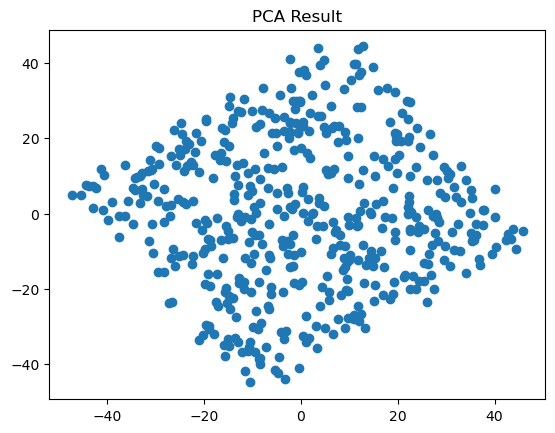

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(matrix)

plt.scatter(pca_result[:,0], pca_result[:,1])
plt.title("PCA Result")
plt.show()

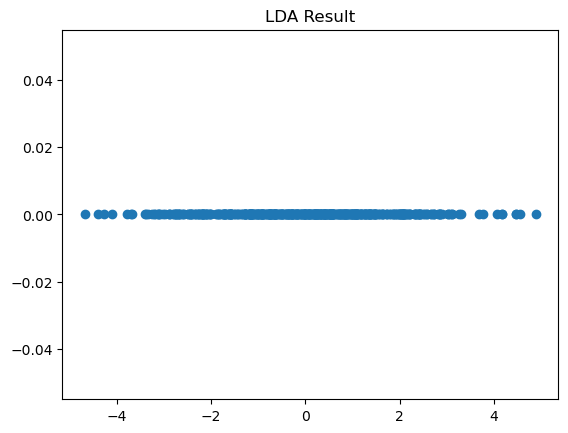

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# create label (Above/Below avg)
labels = (data.mean(axis=1) > data.mean().mean()).astype(int)

lda = LinearDiscriminantAnalysis(n_components=1)
lda_result = lda.fit_transform(matrix, labels)

plt.scatter(lda_result, np.zeros_like(lda_result))
plt.title("LDA Result")
plt.show()